# Antasena Super Course — Perbandingan Efisiensi (KUNCI JAWABAN)

Versi lengkap dari `EDA_ASC.ipynb`: semua grafik sudah ditampilkan dan pertanyaan di Langkah 5 sudah dijawab. **Instruktur:** gunakan notebook ini untuk memeriksa pekerjaan peserta.

## Persiapan (khusus Google Colab)

Jika kamu membuka notebook ini di **Google Colab**, jalankan sel di bawah terlebih dahulu. Sel ini mengunduh kedua file data CSV dari folder `data/` di repo kursus. Di Jupyter lokal, sel ini tidak melakukan apa-apa.

In [1]:
import os, sys, urllib.request

if "google.colab" in sys.modules:
    RAW = "https://raw.githubusercontent.com/Antasena-ITS-Team/ASC_Simulator/master/data/"
    os.makedirs("data", exist_ok=True)
    for nama in ["DataASC_105V_9A.csv", "DataASC_80V_12A.csv", "DataASC_105V_5A.csv", "DataASC_105V_2A.csv"]:
        if not os.path.exists(f"data/{nama}"):
            urllib.request.urlretrieve(RAW + nama, f"data/{nama}")
    print("Data siap:", sorted(os.listdir("data")))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Gaya grafik yang bersih: tanpa bingkai atas/kanan, grid tipis
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold",
})

## Konfigurasi

Setiap baris berisi `(path_csv, label)`.

In [3]:
ATTEMPTS = [
    ("data/DataASC_105V_9A.csv", "105V / 9A"),
    ("data/DataASC_80V_12A.csv", "80V / 12A"),
]

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # aman untuk buta warna dengan urutan ini
COLORS = {label: PALETTE[i % len(PALETTE)] for i, (_, label) in enumerate(ATTEMPTS)}

BASE, OTHER = ATTEMPTS[0][1], ATTEMPTS[1][1]  # percobaan acuan dan pembanding

## Langkah 1 — Memuat data dan menghitung besaran turunan

- `speed_ms` — jika file menyimpan `speed_kmh`, ubah satuannya (**1 m/s = 3,6 km/jam**)
- `power_W = voltage_V × current_A` (daya = tegangan × arus)
- `dt_s` — selang waktu antar baris (`.diff()`)
- `energy_Wh` — jumlah kumulatif `power_W × dt_s`, diubah dari joule (W·s) ke Wh (**1 Wh = 3600 J**)
- `efficiency_km_per_kWh = distance_m / energy_Wh` — kebetulan m/Wh dan km/kWh bernilai sama

**Cek kewajaran:** *nama* kolom belum tentu menjamin *satuannya*. `check_speed_units` membandingkan kolom kecepatan dengan kecepatan yang dihitung dari `distance_m` dan `time_s`. Jika keduanya berbeda 3,6 kali, berarti kolom itu sebenarnya dalam km/jam.

In [4]:
def check_speed_units(df, label):
    implied = df["distance_m"].diff() / df["time_s"].diff()
    moving = df["speed_ms"] > 1
    ratio = (df.loc[moving, "speed_ms"] / implied[moving]).median()
    if abs(ratio - 3.6) < 0.1:
        print(f"[{label}] speed_ms bernilai {ratio:.2f}x kecepatan dari jarak/waktu -> sebenarnya km/jam, dikonversi")
        df["speed_ms"] = df["speed_ms"] / 3.6
    return df


def load_attempt(path, label):
    df = pd.read_csv(path)

    if "speed_kmh" in df.columns:
        df["speed_ms"] = df["speed_kmh"] / 3.6
    df = check_speed_units(df, label)
 #kunci
    df["power_W"] = df["voltage_V"] * df["current_A"]
    df["dt_s"] = df["time_s"].diff().fillna(0)
    df["energy_Wh"] = (df["power_W"] * df["dt_s"] / 3600).cumsum()
    df["efficiency_km_per_kWh"] = np.where(
        df["energy_Wh"] > 0, df["distance_m"] / df["energy_Wh"], np.nan
    )
    df["attempt"] = label
    return df

##
data = {label: load_attempt(path, label) for path, label in ATTEMPTS}

for label, df in data.items():
    print(f"--- {label} ---")
    display(df.head(3))

--- 105V / 9A ---


,lap,time_s,voltage_V,current_A,speed_kmh,distance_m,speed_ms,power_W,dt_s,energy_Wh,efficiency_km_per_kWh,attempt
0,1,0.008,104.998,0.1071,0.000,0.000,0.000000,11.245286,0.0,0.000000,NaN,105V / 9A
1,1,0.208,104.995,0.2857,0.480,0.000,0.133333,29.997072,0.2,0.001667,0.00000,105V / 9A
2,1,0.408,104.990,0.5710,0.959,0.027,0.266389,59.949290,0.2,0.004997,5.40322,105V / 9A


--- 80V / 12A ---


,lap,time_s,voltage_V,current_A,speed_kmh,distance_m,speed_ms,power_W,dt_s,energy_Wh,efficiency_km_per_kWh,attempt
0,1,0.008,79.998,0.1406,0.000,0.000,0.000000,11.247719,0.0,0.000000,NaN,80V / 12A
1,1,0.208,79.993,0.3748,0.480,0.000,0.133333,29.981376,0.2,0.001666,0.000000,80V / 12A
2,1,0.408,79.987,0.7489,0.959,0.027,0.266389,59.902264,0.2,0.004994,5.406991,80V / 12A


## Langkah 2 — Sinyal mentah

Aturan membaca semua grafik di notebook ini: **kedua percobaan selalu digambar bersama**, dan garis putus-putus menunjukkan **rata-rata** masing-masing percobaan (nilainya tertulis di legenda).

- Tegangan dan kecepatan cukup stabil, jadi digambar **terhadap waktu**. Perhatikan bahwa keduanya finis hampir bersamaan (~35 menit), tetapi **pola kecepatannya** sangat berbeda.
- `plot_over_time(column, ylabel, title)` menggambar satu garis untuk setiap percobaan.

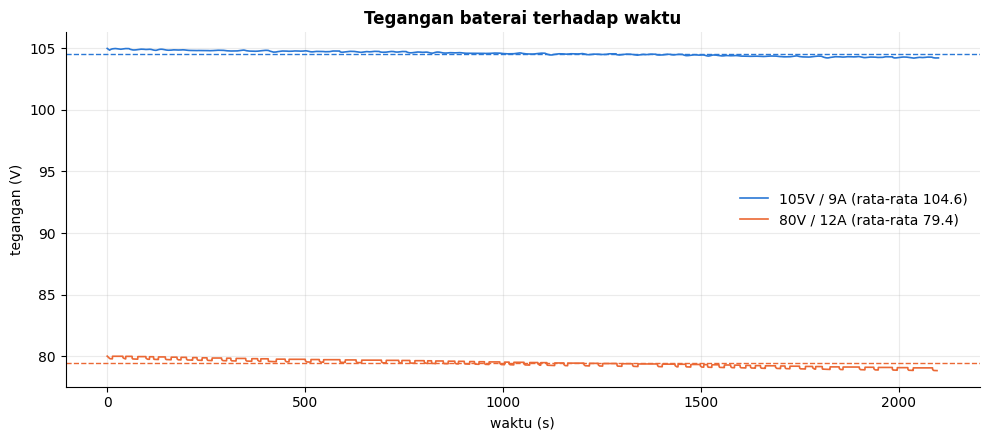

In [5]:
def plot_over_time(column, ylabel, title):
    plt.figure(figsize=(10, 4.5))
    for label, df in data.items():
        avg = df[column].mean()
        plt.plot(df["time_s"], df[column], color=COLORS[label], linewidth=1.2,
                 label=f"{label} (rata-rata {avg:.1f})")
        plt.axhline(avg, color=COLORS[label], linestyle="--", linewidth=1)
    plt.xlabel("waktu (s)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


plot_over_time("voltage_V", "tegangan (V)", "Tegangan baterai terhadap waktu")

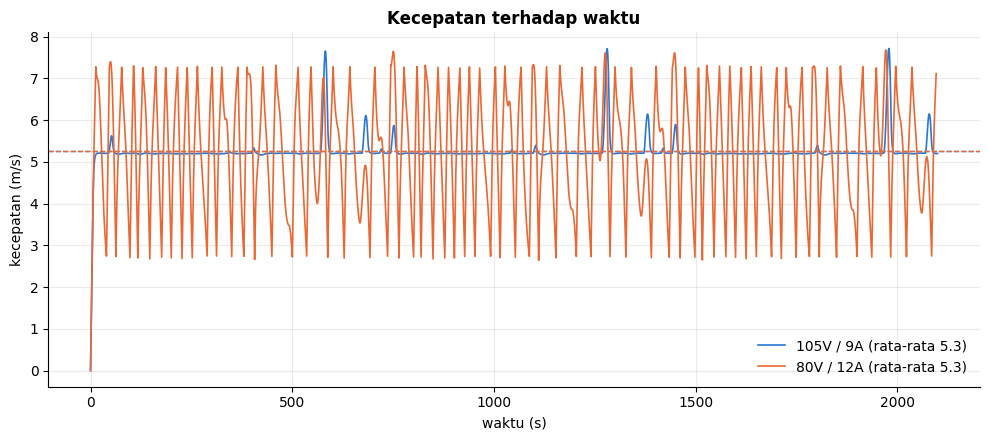

In [6]:
plot_over_time("speed_ms", "kecepatan (m/s)", "Kecepatan terhadap waktu")

### Satu lap, posisi demi posisi

Arus dan daya naik-turun sangat cepat, jadi jika digambar terhadap waktu, kedua garis akan bertumpuk dan sulit dibaca. Selain itu, pada detik yang sama kedua mobil berada di **tempat yang berbeda** di lintasan.

Solusinya: ambil **satu lap** dan gambar terhadap **posisi dalam lap (m)**. Tanjakan dan turunan selalu berada di posisi yang sama, jadi kedua percobaan bisa dibandingkan titik demi titik. **Arsiran abu-abu = selisih antara kedua percobaan.**

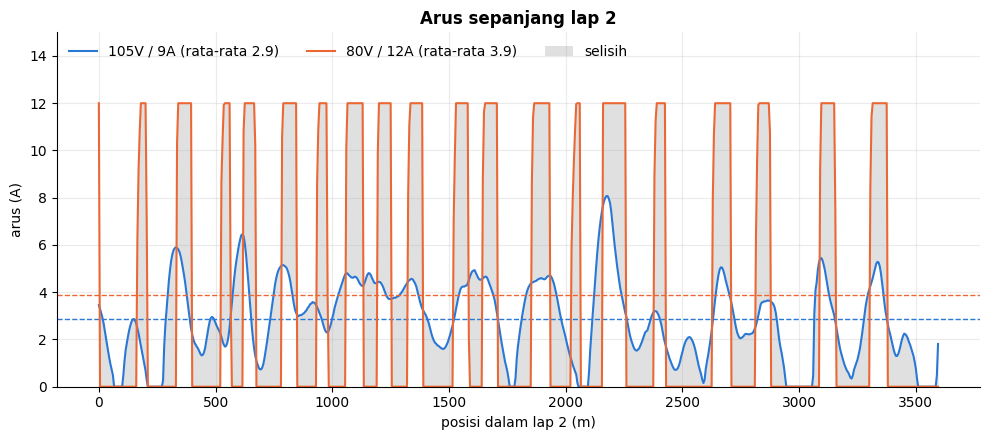

In [7]:
LAP = 2                            # lap tengah: tidak termasuk start dari diam
POS = np.arange(0, 3600, 5)        # posisi dalam lap, setiap 5 m


def plot_one_lap(column, ylabel, title):
    y = {}
    plt.figure(figsize=(10, 4.5))
    for label, df in data.items():
        one = df[df["lap"] == LAP]
        pos = one["distance_m"] - one["distance_m"].iloc[0]   # jarak dari garis start lap
        y[label] = np.interp(POS, pos, one[column])            # samakan titik posisinya
        avg = one[column].mean()
        plt.plot(POS, y[label], color=COLORS[label], linewidth=1.5, label=f"{label} (rata-rata {avg:.1f})")
        plt.axhline(avg, color=COLORS[label], linestyle="--", linewidth=1)
    plt.fill_between(POS, y[BASE], y[OTHER], color="#999", alpha=0.3, linewidth=0, label="selisih")
    plt.ylim(0, max(v.max() for v in y.values()) * 1.25)   # ruang untuk legenda
    plt.xlabel(f"posisi dalam lap {LAP} (m)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(frameon=False, ncol=3, loc="upper left")
    plt.tight_layout()
    plt.show()


plot_one_lap("current_A", "arus (A)", f"Arus sepanjang lap {LAP}")

## Langkah 3 — Daya dan energi

Pada grafik energi terhadap jarak, **garis yang lebih landai = jarak per Wh lebih jauh = lebih efisien.** Arsiran abu-abu adalah energi tambahan yang dipakai percobaan yang lebih boros.

`plot_over_distance(column, ylabel, title, unit)` bekerja seperti `plot_over_time`, tetapi sumbu x-nya **jarak**. Di dalamnya, `np.interp` membaca nilai kedua percobaan di titik jarak yang **sama** (setiap 10 m), supaya selisihnya bisa diarsir. Nilai akhir setiap percobaan ditulis di ujung kanan garis.

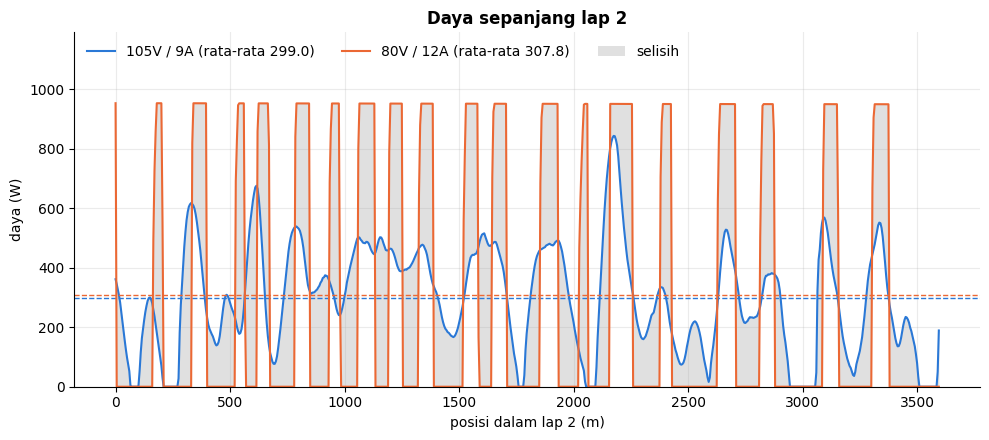

In [8]:
plot_one_lap("power_W", "daya (W)", f"Daya sepanjang lap {LAP}")

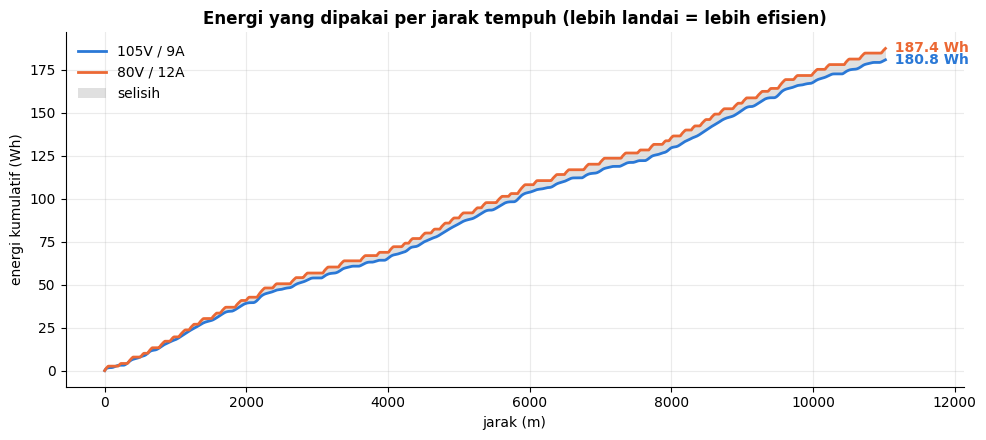

Selisih energi di akhir: 6.6 Wh


In [9]:
def plot_over_distance(column, ylabel, title, unit="", ylim=None, belum_stabil_m=0):
    jarak = np.arange(0, min(df["distance_m"].max() for df in data.values()), 10)
    y = {}
    plt.figure(figsize=(10, 4.5))
    for label, df in data.items():
        y[label] = np.interp(jarak, df["distance_m"], df[column])   # nilai di titik jarak yang sama
        plt.plot(jarak, y[label], color=COLORS[label], linewidth=2, label=label)
        plt.text(jarak[-1], y[label][-1], f"  {y[label][-1]:.1f} {unit}", color=COLORS[label],
                 va="center", fontweight="bold")
    plt.fill_between(jarak, y[BASE], y[OTHER], color="#999", alpha=0.3, linewidth=0, label="selisih")
    if belum_stabil_m:                                                  # bagian awal yang belum stabil
        plt.axvspan(0, belum_stabil_m, color="#999", alpha=0.15, linewidth=0)
        plt.text(belum_stabil_m / 2, ylim[0] + 2, "belum stabil", ha="center", color="#666")
    if ylim:
        plt.ylim(*ylim)
    plt.xlim(right=jarak[-1] * 1.1)                                     # ruang untuk label nilai akhir
    plt.xlabel("jarak (m)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()
    return y


energi = plot_over_distance("energy_Wh", "energi kumulatif (Wh)",
                            "Energi yang dipakai per jarak tempuh (lebih landai = lebih efisien)", unit="Wh")
print(f"Selisih energi di akhir: {energi[OTHER][-1] - energi[BASE][-1]:.1f} Wh")

## Langkah 4 — Perbandingan efisiensi

Efisiensi kumulatif masih naik-turun di awal (karena dibagi energi yang masih sangat kecil, bagian berarsir) lalu stabil seiring berjalannya balapan. Bandingkan nilai **akhirnya**, yang tertulis di ujung kanan setiap garis.

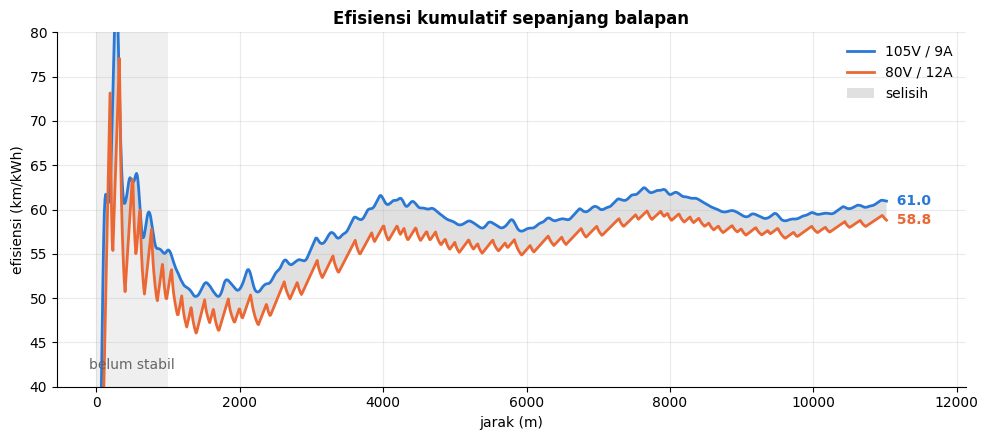

105V / 9A: efisiensi akhir = 60.95 km/kWh
80V / 12A: efisiensi akhir = 58.77 km/kWh
105V / 9A +4% dibanding 80V / 12A


In [10]:
plot_over_distance("efficiency_km_per_kWh", "efisiensi (km/kWh)", "Efisiensi kumulatif sepanjang balapan",
                   ylim=(40, 80), belum_stabil_m=1000)

final = {}
for label, df in data.items():
    final[label] = df["efficiency_km_per_kWh"].iloc[-1]
    print(f"{label}: efisiensi akhir = {final[label]:.2f} km/kWh")
print(f"{BASE} {(final[BASE] / final[OTHER] - 1) * 100:+.0f}% dibanding {OTHER}")

### Ringkasan per lap

Untuk setiap lap: jarak tempuh = `distance_m` terakhir − pertama; begitu juga untuk `energy_Wh`.

In [11]:
summaries = []
for label, df in data.items():
    g = df.groupby("lap").agg(
        distance_start=("distance_m", "first"), distance_end=("distance_m", "last"),
        energy_start=("energy_Wh", "first"), energy_end=("energy_Wh", "last"),
        avg_speed_ms=("speed_ms", "mean"), max_speed_ms=("speed_ms", "max"),
        avg_current_A=("current_A", "mean"),
    )
    g["lap_distance_m"] = g["distance_end"] - g["distance_start"]
    g["lap_energy_Wh"] = g["energy_end"] - g["energy_start"]
    g["lap_efficiency_km_per_kWh"] = g["lap_distance_m"] / g["lap_energy_Wh"]
    g["attempt"] = label
    summaries.append(g.reset_index()[[
        "attempt", "lap", "lap_distance_m", "lap_energy_Wh",
        "lap_efficiency_km_per_kWh", "avg_speed_ms", "max_speed_ms", "avg_current_A",
    ]])

lap_summary = pd.concat(summaries, ignore_index=True)
lap_summary.round(2)

,attempt,lap,lap_distance_m,lap_energy_Wh,lap_efficiency_km_per_kWh,avg_speed_ms,max_speed_ms,avg_current_A
0,105V / 9A,1,3674.24,62.41,58.87,5.22,7.65,3.05
1,105V / 9A,2,3673.98,57.98,63.37,5.26,7.71,2.86
2,105V / 9A,3,3673.79,60.45,60.77,5.26,7.72,2.99
3,80V / 12A,1,3673.69,66.85,54.95,5.22,7.40,4.29
4,80V / 12A,2,3673.76,59.53,61.71,5.27,7.64,3.88
5,80V / 12A,3,3674.28,61.10,60.14,5.29,7.68,4.01


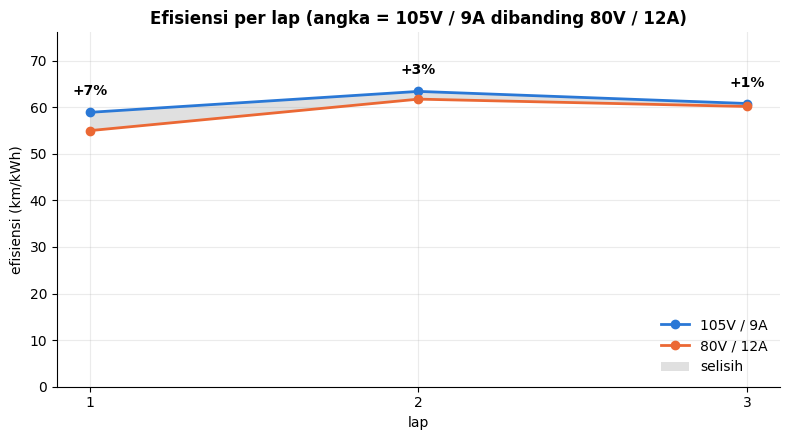

In [12]:
eff_lap = lap_summary.pivot(index="lap", columns="attempt", values="lap_efficiency_km_per_kWh")

plt.figure(figsize=(8, 4.5))
for label in data:
    plt.plot(eff_lap.index, eff_lap[label], color=COLORS[label], marker="o", linewidth=2, label=label)
plt.fill_between(eff_lap.index, eff_lap[BASE], eff_lap[OTHER], color="#999", alpha=0.3, linewidth=0, label="selisih")
for lap in eff_lap.index:
    beda = (eff_lap.loc[lap, BASE] / eff_lap.loc[lap, OTHER] - 1) * 100
    plt.text(lap, eff_lap.loc[lap].max() + 3, f"{beda:+.0f}%", ha="center", va="bottom", fontweight="bold")
plt.xticks(eff_lap.index)
plt.ylim(0, eff_lap.max().max() * 1.2)
plt.xlabel("lap")
plt.ylabel("efisiensi (km/kWh)")
plt.title(f"Efisiensi per lap (angka = {BASE} dibanding {OTHER})")
plt.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

### Catatan kondisi lomba

Lap-lap dalam satu percobaan **tidak identik**, dan kondisi lomba ikut berpengaruh. Log tim mencatat:

| Percobaan | Lap 1 | Lap 2 | Lap 3 |
|---|---|---|---|
| 105V / 9A | ban masih dingin | normal | **angin depan** ~2,5 m/s di bagian terbuka (500–2.000 m) |
| 80V / 12A | ban masih dingin | **angin belakang** ~2 m/s di bagian terbuka (500–2.000 m) | normal |

- **Ban dingin:** hambatan gelinding ban lebih besar sebelum ban mencapai suhu kerjanya (beberapa menit pertama).
- **Angin:** hambatan udara bergantung pada kecepatan mobil **relatif terhadap udara**, `F ∝ (v ± w)²`. Angin depan menambah beban, angin belakang menguranginya. Kontroler menjaga kecepatan tetap, jadi perubahan beban itu terlihat sebagai perubahan **arus**, bukan kecepatan.

Coba ganti `LAP = 2` di Langkah 2 menjadi `LAP = 3`, lalu jalankan ulang grafik arus. Apa yang berubah di bagian 500–2.000 m?

## Langkah 5 — Mengapa efisiensinya berbeda?

Tabel di bawah mengumpulkan angka-angka yang kamu perlukan untuk menjawab pertanyaan.

In [13]:
overall = pd.DataFrame({
    label: {
        "efisiensi akhir (km/kWh)": df["efficiency_km_per_kWh"].iloc[-1],
        "total energi (Wh)": df["energy_Wh"].iloc[-1],
        "rata-rata tegangan (V)": df["voltage_V"].mean(),
        "rata-rata arus (A)": df["current_A"].mean(),
        "rata-rata arus² (A²)": (df["current_A"] ** 2).mean(),
        "rata-rata kecepatan (m/s)": df["speed_ms"].mean(),
        "kecepatan maks (m/s)": df["speed_ms"].max(),
        "waktu tempuh (s)": df["time_s"].iloc[-1],
    }
    for label, df in data.items()
})
overall.round(2)

,105V / 9A,80V / 12A
efisiensi akhir (km/kWh),60.95,58.77
total energi (Wh),180.88,187.59
rata-rata tegangan (V),104.59,79.43
rata-rata arus (A),2.97,4.06
rata-rata arus² (A²),11.88,47.20
rata-rata kecepatan (m/s),5.25,5.26
kecepatan maks (m/s),7.72,7.68
waktu tempuh (s),2099.81,2096.21


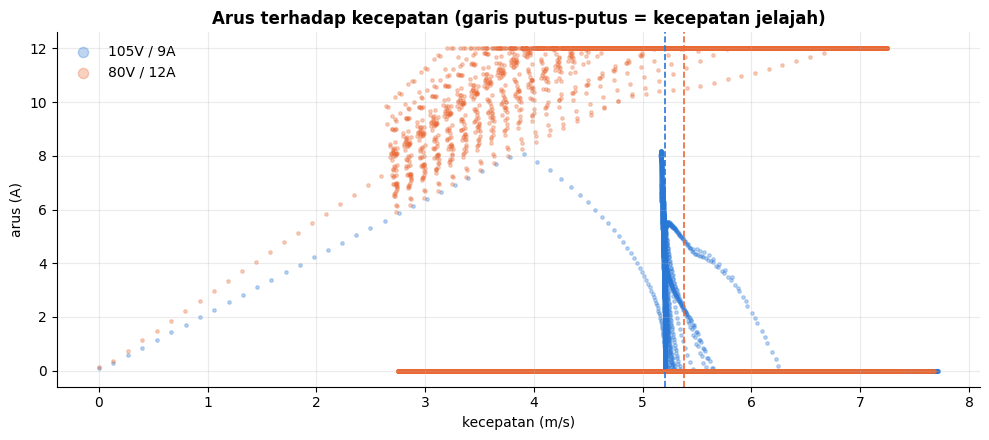

In [14]:
plt.figure(figsize=(10, 4.5))
for label, df in data.items():
    plt.scatter(df["speed_ms"], df["current_A"], color=COLORS[label], s=6, alpha=0.3, label=label)
    plt.axvline(df["speed_ms"].median(), color=COLORS[label], linestyle="--", linewidth=1.2)
plt.xlabel("kecepatan (m/s)")
plt.ylabel("arus (A)")
plt.title("Arus terhadap kecepatan (garis putus-putus = kecepatan jelajah)")
plt.legend(frameon=False, markerscale=3)
plt.tight_layout()
plt.show()

### P1. Percobaan mana yang efisiensinya lebih tinggi, dan kira-kira berapa persen selisihnya?

**Jawaban:** **105V / 9A lebih unggul: ≈ 61,0 km/kWh vs ≈ 58,8 km/kWh, sekitar 4% lebih efisien.** Kedua percobaan menempuh jarak yang sama (~11,03 km) dalam waktu yang **sama** (~35 menit), tetapi 105V hanya memakai ~181 Wh sedangkan 80V ~188 Wh. Grafik per lap menunjukkan 105V unggul di **setiap** lap (+7%, +3%, +1%), jadi ini perbedaan yang nyata. Besar keunggulannya berubah-ubah karena kondisi lomba (lihat catatan kondisi lomba): di lap 1 kedua mobil terhambat ban dingin dan mobil 80V juga paling banyak menghentak gas saat start, di lap 2 mobil 80V dibantu angin belakang, dan di lap 3 mobil 105V melawan angin depan.

### P2. Bandingkan `avg_current_A` antar percobaan. Rugi-rugi listrik sebanding dengan **kuadrat arus** (`P_rugi ≈ I² × R`). Bagaimana hal ini bisa menjelaskan sebagian perbedaannya?

**Jawaban:** Rata-rata arus **≈ 3,0 A (105V) vs ≈ 4,1 A (80V)**, sekitar 1,4 kali, tetapi rata-rata *I²* **≈ 12 vs ≈ 47 A²**, hampir **4 kali**. Mengapa rasio I² jauh lebih besar dari rasio I? Karena mobil 80V tidak menarik arus secara merata: arusnya hampir selalu **0 A (gliding) atau 12 A (gas penuh)**. Kuadrat dari 12 A adalah 144, jadi setiap detik gas penuh menghasilkan panas yang sangat besar. Rugi-rugi pada kabel, lilitan motor, dan kontroler sebanding dengan I², jadi dengan hambatan yang sama percobaan 80V membuang ~4 kali lebih banyak energi sebagai panas. Tegangan yang lebih rendah menambah masalah: untuk daya yang sama, 80V butuh arus ~30% lebih besar. Langkah 6.4 menunjukkan bahwa kali ini I²R menjelaskan **sebagian besar** selisih energi.

### P3. Apakah percobaan yang lebih efisien juga mencapai kecepatan puncak lebih tinggi? Apa artinya bagi tarik-ulur antara kecepatan dan efisiensi?

**Jawaban:** **Kecepatannya ternyata sama.** Kedua percobaan finis dalam ~35 menit dengan rata-rata ≈ 5,3 m/s (≈ 19 km/jam), dan puncaknya pun hampir sama (≈ 7,7 m/s di turunan). Yang berbeda adalah **cara** mencapai rata-rata itu: 105V melaju stabil di ~19 km/jam, sedangkan 80V berayun antara ~10 dan ~28 km/jam (gas penuh, lalu gliding, lalu gas lagi). Jadi dengan waktu tempuh yang sama, efisiensi ditentukan oleh **gaya mengemudi**: kecepatan yang naik-turun membutuhkan arus puncak besar (rugi I²R besar) dan sedikit hambatan udara tambahan (rata-rata v² ~6% lebih besar walaupun rata-rata v sama).

⚠️ *Catatan:* satuan sangat penting di sini. Jika kecepatan (tersimpan dalam km/jam) dibaca sebagai m/s, seolah-olah mobil melaju 19 m/s (68 km/jam), yang merupakan kesimpulan yang salah. Cek satuan di Langkah 1 melindungi dari kolom kecepatan yang salah label.

### P4. Lihat grafik arus terhadap kecepatan: pada kecepatan yang mirip, apakah salah satu percobaan menarik arus jauh lebih besar? Apa penyebabnya (rasio gir, ukuran motor, hambatan aerodinamis, gaya mengemudi)?

**Jawaban:** Ya. Titik-titik 105V berkumpul di satu garis tegak di kecepatan jelajahnya (~5,2 m/s) dengan arus 0–8 A sesuai tanjakan. Titik-titik 80V membentuk **dua garis mendatar**: di **12 A** (gas penuh, batas kontroler) dan di **0 A** (gliding), di hampir semua kecepatan antara ~3 dan ~7 m/s. Jadi pada kecepatan yang sama, 80V menarik arus 12 A atau tidak sama sekali, sedangkan 105V hanya menarik arus secukupnya untuk menjaga kecepatan. Penyebab utamanya adalah **gaya mengemudi** (gas-glide vs stabil), ditambah **tegangan lebih rendah** (butuh ampere lebih besar untuk daya yang sama). Gliding sendiri bukan masalah; masalahnya adalah fase gas penuh yang harus mengembalikan kecepatan yang hilang saat gliding.

## Langkah 6 — Lanjutan: apa di balik angka-angka ini

Grafik di atas menunjukkan *bahwa* 105V / 9A lebih efisien. Grafik di bawah menunjukkan *mengapa*: di bagian lintasan mana energi tambahan terpakai, bagaimana setiap percobaan dikemudikan, dan seberapa besar selisih yang masuk akal dijelaskan oleh setiap penyebab fisik.

Bagian ini mengasumsikan tepat dua percobaan: entri pertama di `ATTEMPTS` adalah acuan (baseline) dan entri kedua dibandingkan terhadapnya.

In [15]:
LAP_BIN_M = 25                      # resolusi profil posisi dalam lap

for label, df in data.items():
    df["seg_Wh"] = df["power_W"] * df["dt_s"] / 3600
    df["seg_m"] = df["distance_m"].diff().fillna(0)
    df["lap_pos_m"] = df["distance_m"] - df.groupby("lap")["distance_m"].transform("first")
    df["pos_bin"] = (df["lap_pos_m"] // LAP_BIN_M) * LAP_BIN_M


def lap_profile(df):
    """Rata-rata kecepatan/arus dan intensitas energi di setiap posisi dalam lap."""
    n_laps = df["lap"].nunique()
    prof = df.groupby("pos_bin").agg(
        speed=("speed_ms", "mean"), current=("current_A", "mean"), E=("seg_Wh", "sum"))
    prof["Wh_per_km"] = prof["E"] / n_laps / LAP_BIN_M * 1000
    return prof


profiles = {label: lap_profile(df) for label, df in data.items()}


def shade_gap(ax, x, base, other, label=True):
    """Arsir area di antara dua garis: oranye bila pembanding lebih tinggi, biru bila acuan lebih tinggi."""
    base, other = np.asarray(base), np.asarray(other)
    ax.fill_between(x, base, other, where=other >= base, interpolate=True,
                    color=COLORS[OTHER], alpha=0.22, linewidth=0,
                    label=f"{OTHER} lebih tinggi" if label else None)
    ax.fill_between(x, base, other, where=other < base, interpolate=True,
                    color=COLORS[BASE], alpha=0.22, linewidth=0,
                    label=f"{BASE} lebih tinggi" if label else None)

### 6.1 Satu lap, posisi demi posisi

Setiap lap menempuh lintasan yang sama sepanjang ~3.675 m, jadi semua lap bisa disejajarkan berdasarkan **posisi dalam lap** lalu dirata-ratakan. Cara ini memisahkan *pengaruh lintasan* (tanjakan dan tikungan selalu berada di tempat yang sama setiap lap) dari *pengaruh pengemudi*.

Kedua percobaan selalu digambar sebagai garis. **Area di antara kedua garis diarsir** dengan warna percobaan yang nilainya lebih tinggi, sehingga besar dan arah selisihnya terlihat langsung. Pita abu-abu menandai bagian di mana selisih energinya paling besar (lihat 6.2).

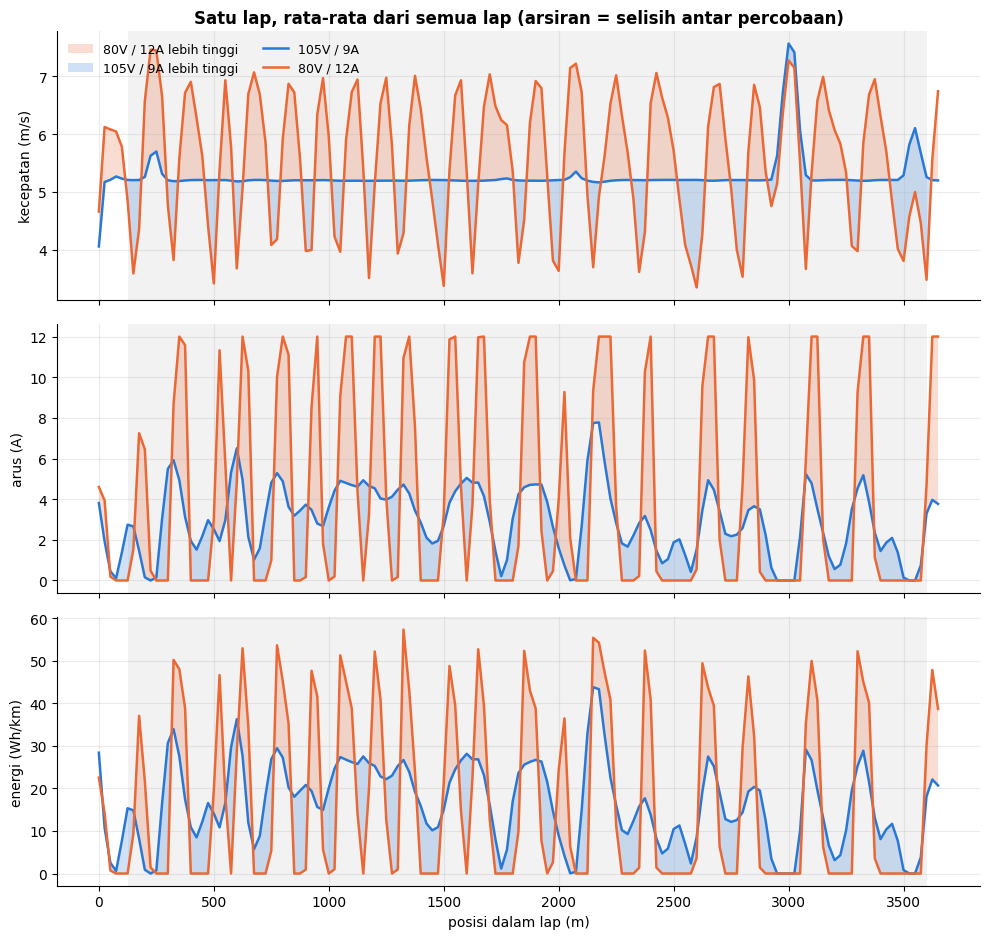

In [16]:
diff = (profiles[OTHER]["Wh_per_km"] - profiles[BASE]["Wh_per_km"]).rolling(8, center=True).mean()
hot = diff[diff > diff.quantile(0.75)].index
band = (hot.min(), hot.max() + LAP_BIN_M) if len(hot) else None

fig, axes = plt.subplots(3, 1, figsize=(10, 9.5), sharex=True)
rows = [("speed", "kecepatan (m/s)"), ("current", "arus (A)"), ("Wh_per_km", "energi (Wh/km)")]
x = profiles[BASE].index.intersection(profiles[OTHER].index)
for i, (ax, (col, ylabel)) in enumerate(zip(axes, rows)):
    if band:
        ax.axvspan(*band, color="#888", alpha=0.10, linewidth=0)
    shade_gap(ax, x, profiles[BASE].loc[x, col], profiles[OTHER].loc[x, col], label=(i == 0))
    for label in (BASE, OTHER):
        ax.plot(x, profiles[label].loc[x, col], color=COLORS[label], linewidth=1.8, label=label)
    ax.set_ylabel(ylabel)
axes[0].set_title("Satu lap, rata-rata dari semua lap (arsiran = selisih antar percobaan)")
axes[0].legend(frameon=False, loc="upper left", ncol=2, fontsize=9)
axes[-1].set_xlabel("posisi dalam lap (m)")
fig.tight_layout()
plt.show()

**Cara membacanya:**

- **Kecepatan:** 105V hampir datar di ~5,2 m/s. 80V berupa gigi gergaji: naik saat gas penuh, turun saat gliding. Karena dirata-ratakan dari tiga lap, polanya sedikit teredam, tetapi rata-rata keduanya sama. Lonjakan di sekitar 3.000 m adalah turunan: kedua mobil bertambah cepat dengan arus 0 A.
- **Arus:** 105V naik-turun mengikuti tanjakan. 80V melompat antara 0 dan 12 A tanpa terlalu peduli tanjakan, karena yang menentukan kapan gas ditekan adalah kecepatannya.
- **Energi per km:** puncak oranye muncul di setiap fase gas penuh, dan lembah oranye di setiap fase gliding. Arsiran oranye (80V lebih boros) lebih banyak daripada arsiran biru, karena energi yang "dihemat" saat gliding harus dibayar kembali dengan arus 12 A.

### 6.2 Di mana selisih energi terkumpul?

- **Atas:** energi kumulatif **kedua** percobaan terhadap jarak. Area arsiran di antara kedua garis adalah energi tambahan yang sudah dipakai percobaan 80V.
- **Tengah:** tinggi area arsiran tersebut digambar sebagai satu garis (selisih kumulatif), supaya polanya per lap terlihat jelas.
- **Bawah:** energi per 100 m di setiap posisi dalam lap untuk **kedua** percobaan (dirata-ratakan antar lap). Arsiran oranye = bagian di mana 80V memakai energi lebih banyak, arsiran biru = bagian di mana 105V yang lebih banyak. Inilah bagian lap yang menyumbang selisih.

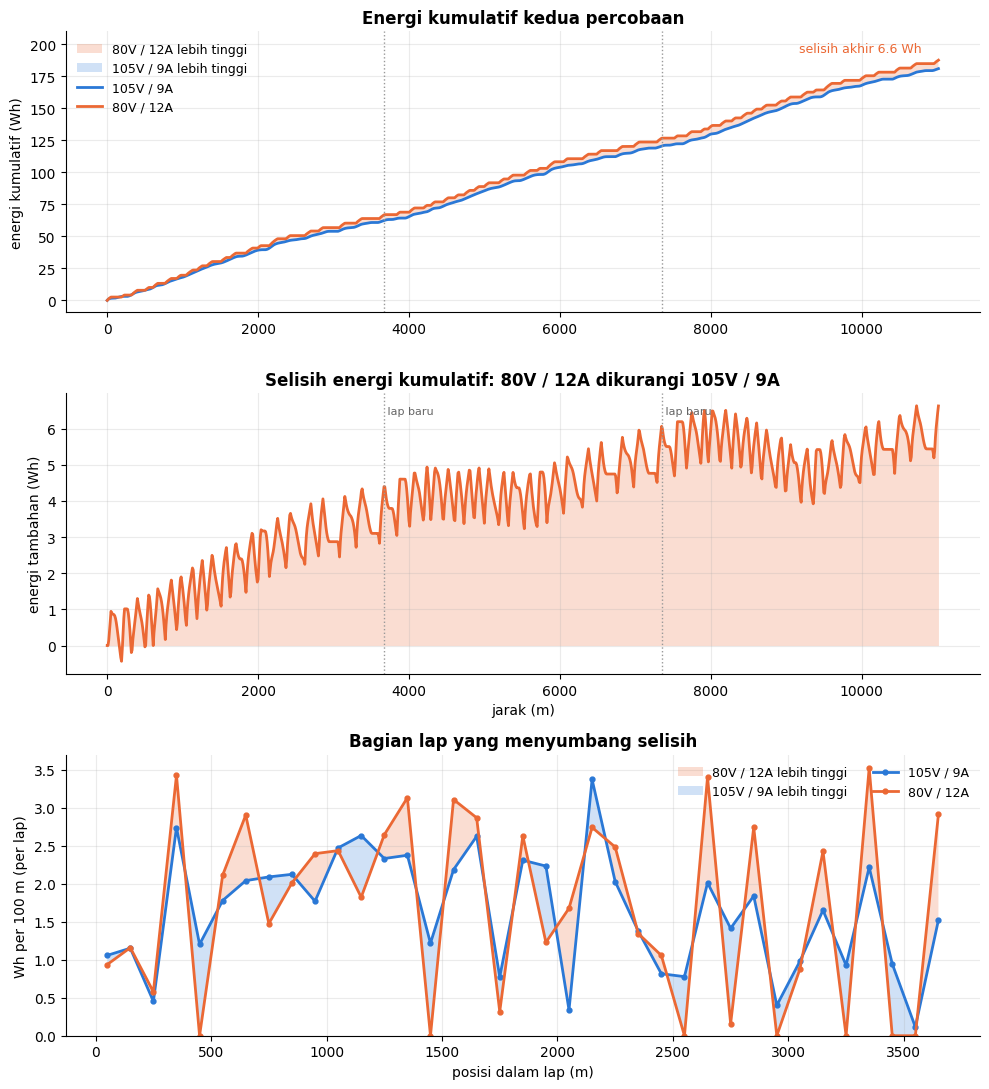

Total selisih: 6.6 Wh sepanjang 11.0 km
Porsi selisih per lap dari bagian 500-2000 m: 6%


In [17]:
grid = np.arange(0, min(df["distance_m"].iloc[-1] for df in data.values()), 10)
e_at = {label: np.interp(grid, df["distance_m"], df["energy_Wh"]) for label, df in data.items()}
gap = e_at[OTHER] - e_at[BASE]

SEG = 100
seg_E = pd.DataFrame({
    label: df.groupby((df["lap_pos_m"] // SEG) * SEG)["seg_Wh"].sum() / df["lap"].nunique()
    for label, df in data.items()
}).dropna()
seg_x = seg_E.index + SEG / 2
seg_diff = seg_E[OTHER] - seg_E[BASE]
lap_starts = data[BASE].groupby("lap")["distance_m"].first().iloc[1:]

fig = plt.figure(figsize=(10, 11))
ax1 = fig.add_subplot(3, 1, 1)
ax2 = fig.add_subplot(3, 1, 2, sharex=ax1)
ax3 = fig.add_subplot(3, 1, 3)

# (atas) kedua percobaan + arsiran selisih
shade_gap(ax1, grid, e_at[BASE], e_at[OTHER])
for label in (BASE, OTHER):
    ax1.plot(grid, e_at[label], color=COLORS[label], linewidth=2, label=label)
ax1.annotate(f"selisih akhir {gap[-1]:.1f} Wh", xy=(grid[-1], e_at[OTHER][-1]), xytext=(-12, 4),
             textcoords="offset points", ha="right", va="bottom", fontsize=9, color=COLORS[OTHER])
ax1.set_ylim(top=e_at[OTHER][-1] * 1.12)
ax1.set_ylabel("energi kumulatif (Wh)")
ax1.set_title("Energi kumulatif kedua percobaan")
ax1.legend(frameon=False, loc="upper left", fontsize=9)

# (tengah) tinggi arsiran = selisih kumulatif
ax2.plot(grid, gap, color=COLORS[OTHER], linewidth=2)
ax2.fill_between(grid, 0, gap, color=COLORS[OTHER], alpha=0.22, linewidth=0)
for d in lap_starts:
    for ax in (ax1, ax2):
        ax.axvline(d, color="#999", linestyle=":", linewidth=1)
    ax2.text(d, gap.max(), " lap baru", color="#666", fontsize=8, va="top")
ax2.set_xlabel("jarak (m)")
ax2.set_ylabel("energi tambahan (Wh)")
ax2.set_title(f"Selisih energi kumulatif: {OTHER} dikurangi {BASE}")

# (bawah) kedua percobaan per posisi dalam lap + arsiran selisih
shade_gap(ax3, seg_x, seg_E[BASE], seg_E[OTHER])
for label in (BASE, OTHER):
    ax3.plot(seg_x, seg_E[label], color=COLORS[label], linewidth=2, marker="o", markersize=3.5, label=label)
ax3.set_ylim(bottom=0)
ax3.set_xlabel("posisi dalam lap (m)")
ax3.set_ylabel("Wh per 100 m (per lap)")
ax3.set_title("Bagian lap yang menyumbang selisih")
ax3.legend(frameon=False, loc="upper right", ncol=2, fontsize=9)
fig.tight_layout()
plt.show()

share = seg_diff[(seg_diff.index >= 500) & (seg_diff.index < 2000)].sum() / seg_diff.sum()
print(f"Total selisih: {gap[-1]:.1f} Wh sepanjang {grid[-1] / 1000:.1f} km")
print(f"Porsi selisih per lap dari bagian 500-2000 m: {share:.0%}")

**Cara membacanya:** pada grafik atas kedua garis energi hampir berimpit, dan arsiran di antaranya tipis: selisih totalnya hanya ~6,6 Wh (~4%). Grafik tengah berbentuk gigi gergaji: selisih **naik** setiap kali mobil 80V gas penuh dan **turun** sedikit saat mobil 80V gliding sementara 105V masih menarik arus. Tambahannya berbeda per lap (~4,4 Wh, ~1,6 Wh, ~0,7 Wh). Lap 1 paling besar karena mobil 80V mulai dari diam dengan gas penuh. Lap 2 dan 3 mengecil karena mobil 80V dibantu angin belakang di lap 2, dan mobil 105V melawan angin depan di lap 3. Grafik bawah menunjukkan selisih tersebar di seluruh lap, tidak terkumpul di satu bagian: yang menentukan adalah *pola gas-glide*, bukan bagian lintasan tertentu.

### 6.3 Bagaimana setiap percobaan dikemudikan

- **Kiri atas: distribusi kecepatan** (berbobot waktu). Kedua percobaan digambar sebagai garis, garis putus-putus adalah **median**, dan panah Δ menunjukkan besar pergeserannya.
- **Kanan atas: gliding vs bertenaga.** Seluruh waktu balapan setiap percobaan dibagi menjadi tiga mode: **gliding** (arus ~0 A tetapi mobil tetap melaju, energi gratis), bertenaga ≤ 7 A, dan bertenaga > 7 A.
- **Bawah: di mana gliding terjadi.** Persentase waktu gliding di setiap posisi dalam lap untuk kedua percobaan. Arsiran biru = 105V lebih sering gliding di bagian itu, arsiran oranye = 80V lebih sering.

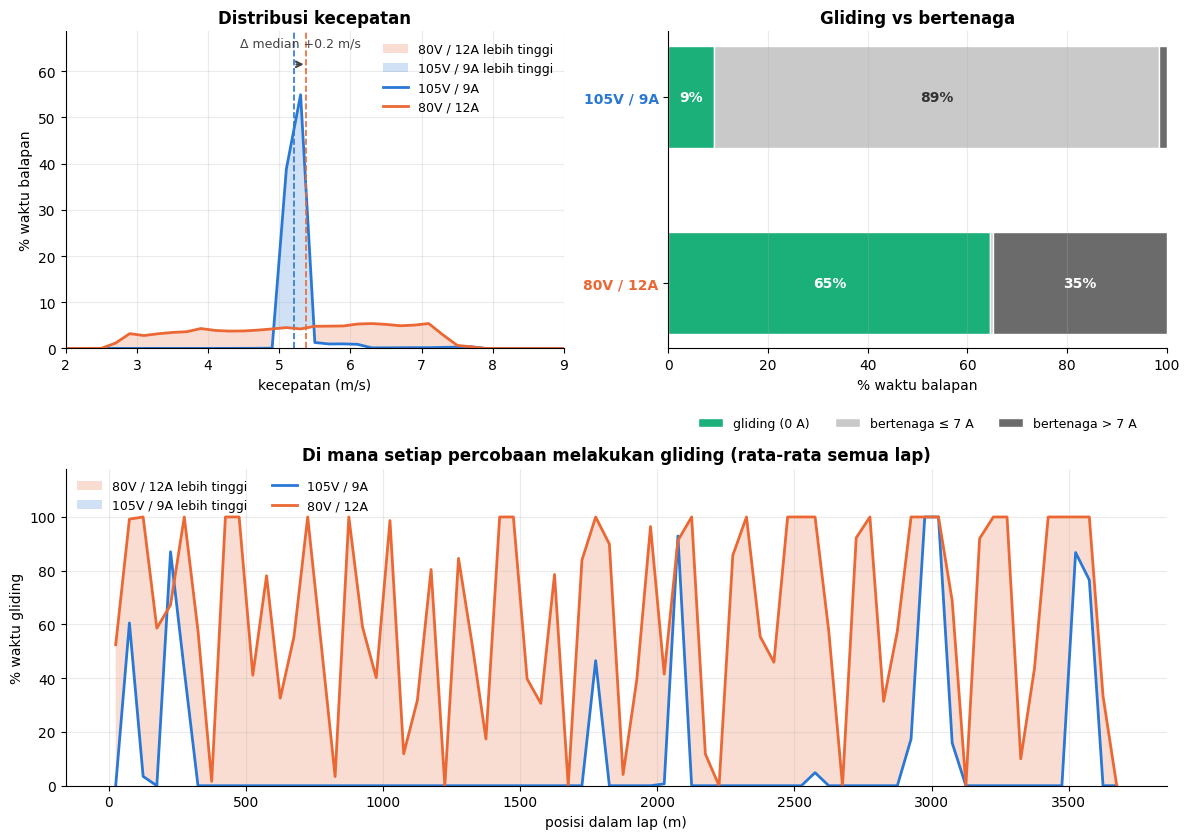

105V / 9A: gliding 9% dari waktu (10% dari jarak), di atas 7 A 1% dari waktu
80V / 12A: gliding 65% dari waktu (64% dari jarak), di atas 7 A 35% dari waktu


In [18]:
def time_hist(values, dt, bins):
    """Persen waktu balapan di setiap bin (berbobot dt)."""
    h, edges = np.histogram(values, bins=bins, weights=dt / dt.sum() * 100)
    return (edges[:-1] + edges[1:]) / 2, h


def weighted_median(values, dt):
    order = np.argsort(values.to_numpy())
    cum = dt.to_numpy()[order].cumsum()
    return values.to_numpy()[order][np.searchsorted(cum, cum[-1] / 2)]


def plot_distribution(ax, column, bins, unit, xlim):
    hist, med = {}, {}
    for label, df in data.items():
        x, hist[label] = time_hist(df[column], df["dt_s"], bins)
        med[label] = weighted_median(df[column], df["dt_s"])
    shade_gap(ax, x, hist[BASE], hist[OTHER])
    for label in (BASE, OTHER):
        ax.plot(x, hist[label], color=COLORS[label], linewidth=2, label=label)
        ax.axvline(med[label], color=COLORS[label], linestyle="--", linewidth=1.2)
    top = max(h.max() for h in hist.values())
    ax.set_ylim(0, top * 1.25)
    y = top * 1.12
    ax.annotate("", xy=(med[OTHER], y), xytext=(med[BASE], y),
                arrowprops=dict(arrowstyle="->", color="#444", linewidth=1.5))
    ax.text((med[BASE] + med[OTHER]) / 2, y, f"Δ median {med[OTHER] - med[BASE]:+.1f} {unit}\n",
            ha="center", va="bottom", fontsize=9, color="#444")
    ax.set_xlim(*xlim)
    ax.set_ylabel("% waktu balapan")
    return med


# Mode mengemudi: gliding = arus ~0 A sambil tetap melaju
GLIDE_BIN = 50
MODES = [("gliding (0 A)", "#1baf7a"), ("bertenaga ≤ 7 A", "#c9c9c9"), ("bertenaga > 7 A", "#6b6b6b")]
for label, df in data.items():
    df["gliding"] = (df["current_A"] < 0.2) & (df["speed_ms"] > 1)
    df["mode"] = np.select([df["gliding"], df["current_A"] > 7], [MODES[0][0], MODES[2][0]], MODES[1][0])

share = pd.DataFrame({
    label: df.groupby("mode")["dt_s"].sum() / df["dt_s"].sum() * 100 for label, df in data.items()
}).T[[m for m, _ in MODES]].fillna(0)

glide_pos = pd.DataFrame({
    label: df.groupby((df["lap_pos_m"] // GLIDE_BIN) * GLIDE_BIN)
             .apply(lambda g: g.loc[g["gliding"], "dt_s"].sum() / g["dt_s"].sum() * 100)
    for label, df in data.items()
}).dropna()
glide_x = glide_pos.index + GLIDE_BIN / 2

fig = plt.figure(figsize=(12, 8.5))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

# (kiri atas) distribusi kecepatan
plot_distribution(ax1, "speed_ms", np.arange(0, 10.01, 0.2), "m/s", xlim=(2, 9))
ax1.set_xlabel("kecepatan (m/s)")
ax1.set_title("Distribusi kecepatan")
ax1.legend(frameon=False, loc="upper right", fontsize=9)

# (kanan atas) porsi waktu: gliding vs bertenaga
rows = [BASE, OTHER][::-1]
left = np.zeros(len(rows))
for mode, color in MODES:
    vals = share.loc[rows, mode].to_numpy()
    ax2.barh(rows, vals, left=left, color=color, height=0.55, label=mode, edgecolor="white")
    for yi, (l, v) in enumerate(zip(left, vals)):
        if v >= 4:
            ax2.text(l + v / 2, yi, f"{v:.0f}%", ha="center", va="center", fontsize=10,
                     color="white" if color != "#c9c9c9" else "#333", fontweight="bold")
    left += vals
for tick, label in zip(ax2.get_yticklabels(), rows):
    tick.set_color(COLORS[label]); tick.set_fontweight("bold")
ax2.set_xlim(0, 100)
ax2.set_xlabel("% waktu balapan")
ax2.set_title("Gliding vs bertenaga")
ax2.grid(axis="y", visible=False)
ax2.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=9)

# (bawah) di mana gliding terjadi dalam satu lap
shade_gap(ax3, glide_x, glide_pos[BASE], glide_pos[OTHER])
for label in (BASE, OTHER):
    ax3.plot(glide_x, glide_pos[label], color=COLORS[label], linewidth=2, label=label)
only_base = (glide_pos[BASE] - glide_pos[OTHER])
only_base = only_base[(only_base > 30) & (only_base == only_base.rolling(3, center=True, min_periods=1).max())]
for pos in only_base.index:
    ax3.annotate(f"hanya {BASE}\ngliding", (pos + GLIDE_BIN / 2, glide_pos.loc[pos, BASE]),
                 xytext=(0, 6), textcoords="offset points", ha="center", va="bottom",
                 fontsize=8.5, color=COLORS[BASE])
ax3.set_ylim(0, 118)
ax3.set_xlabel("posisi dalam lap (m)")
ax3.set_ylabel("% waktu gliding")
ax3.set_title("Di mana setiap percobaan melakukan gliding (rata-rata semua lap)")
ax3.legend(frameon=False, loc="upper left", ncol=2, fontsize=9)
fig.tight_layout()
plt.show()

for label, df in data.items():
    glide_m = df.loc[df["gliding"], "seg_m"].sum()
    print(f"{label}: gliding {share.loc[label, MODES[0][0]]:.0f}% dari waktu "
          f"({glide_m / df['seg_m'].sum():.0%} dari jarak), di atas 7 A {share.loc[label, MODES[2][0]]:.0f}% dari waktu")

**Cara membacanya:** distribusi kecepatan 105V berupa satu puncak tajam di ~5,2 m/s, sedangkan distribusi 80V melebar datar dari ~3 sampai ~7 m/s. Mediannya hampir sama (panah Δ sangat pendek), jadi **bukan kecepatan yang dipilih yang berbeda, melainkan kestabilannya**.

Grafik gliding menunjukkan strategi 80V dengan jelas: mobil 80V gliding **65%** dari waktu balapan, jauh lebih banyak dari 105V (**9%**). Tetapi sisanya hampir selalu di **gas penuh**: **35%** waktunya di atas 7 A, sedangkan 105V hanya 1%. Grafik bawah menunjukkan mobil 80V gliding hampir di mana saja di lintasan, sedangkan 105V hanya gliding di turunan (~3.000 m dan awal/akhir lap).

**Pelajaran penting:** lebih sering gliding **tidak otomatis** lebih hemat. Gliding hanya gratis jika turunan yang mendorong mobil (seperti 105V di ~3.000 m). Gliding di jalan datar berarti mobil kehilangan kecepatan, dan kecepatan itu harus dibeli kembali dengan arus besar.

### 6.4 Seberapa besar rugi-rugi I²R bisa menjelaskan?

Rugi-rugi resistif adalah `E_rugi = R × ∫I² dt`. Kita tahu `∫I² dt` setiap percobaan dari data, tetapi tidak tahu total hambatan `R` dari baterai, kabel, kontroler, dan lilitan motor. Sistem nyata seukuran ini biasanya berada di sekitar 0,05–0,3 Ω (berarsir abu-abu).

- **Kiri:** rugi I²R **setiap percobaan** untuk setiap kemungkinan nilai R. Arsiran di antara kedua garis adalah rugi tambahan percobaan 80V.
- **Kanan:** tinggi arsiran tersebut dibandingkan dengan total selisih energi yang terukur: **berapa bagian selisih yang bisa dijelaskan oleh rugi-rugi resistif**.

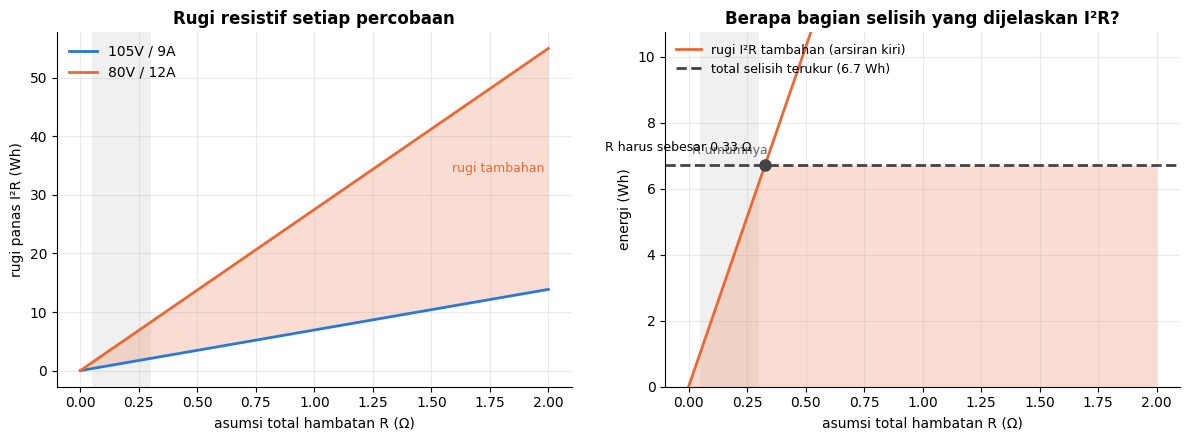

Pada R = 0.1 Ω: I²R menjelaskan 2.1 Wh = 31% dari selisih
Pada R = 0.3 Ω: I²R menjelaskan 6.2 Wh = 92% dari selisih


In [19]:
i2t = {label: (df["current_A"] ** 2 * df["dt_s"]).sum() for label, df in data.items()}  # A²·s
total_gap_Wh = data[OTHER]["energy_Wh"].iloc[-1] - data[BASE]["energy_Wh"].iloc[-1]

R = np.linspace(0, 2, 201)
loss_Wh = {label: R * i2t[label] / 3600 for label in data}
loss_gap_Wh = loss_Wh[OTHER] - loss_Wh[BASE]
R_full = total_gap_Wh * 3600 / (i2t[OTHER] - i2t[BASE])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

# (kiri) rugi I²R kedua percobaan
ax1.axvspan(0.05, 0.3, color="#888", alpha=0.12, linewidth=0)
shade_gap(ax1, R, loss_Wh[BASE], loss_Wh[OTHER], label=False)
for label in (BASE, OTHER):
    ax1.plot(R, loss_Wh[label], color=COLORS[label], linewidth=2, label=label)
ax1.text(R[-1], (loss_Wh[BASE][-1] + loss_Wh[OTHER][-1]) / 2, "rugi tambahan ",
         ha="right", va="center", color=COLORS[OTHER], fontsize=9)
ax1.set_xlabel("asumsi total hambatan R (Ω)")
ax1.set_ylabel("rugi panas I²R (Wh)")
ax1.set_title("Rugi resistif setiap percobaan")
ax1.legend(frameon=False, loc="upper left")

# (kanan) rugi tambahan vs total selisih terukur
ax2.axvspan(0.05, 0.3, color="#888", alpha=0.12, linewidth=0)
ax2.text(0.175, total_gap_Wh * 1.05, "R umumnya", ha="center", color="#666", fontsize=9)
ax2.fill_between(R, 0, np.minimum(loss_gap_Wh, total_gap_Wh), color=COLORS[OTHER], alpha=0.22, linewidth=0)
ax2.plot(R, loss_gap_Wh, color=COLORS[OTHER], linewidth=2, label="rugi I²R tambahan (arsiran kiri)")
ax2.axhline(total_gap_Wh, color="#444", linewidth=2, linestyle="--",
            label=f"total selisih terukur ({total_gap_Wh:.1f} Wh)")
ax2.plot([R_full], [total_gap_Wh], "o", color="#444", markersize=8)
ax2.annotate(f"R harus sebesar {R_full:.2f} Ω", (R_full, total_gap_Wh),
             xytext=(-10, 10), textcoords="offset points", ha="right", fontsize=9)
ax2.set_ylim(0, total_gap_Wh * 1.6)
ax2.set_xlabel("asumsi total hambatan R (Ω)")
ax2.set_ylabel("energi (Wh)")
ax2.set_title("Berapa bagian selisih yang dijelaskan I²R?")
ax2.legend(frameon=False, loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

for r in (0.1, 0.3):
    print(f"Pada R = {r} Ω: I²R menjelaskan {r * (i2t[OTHER] - i2t[BASE]) / 3600:.1f} Wh "
          f"= {r * (i2t[OTHER] - i2t[BASE]) / 3600 / total_gap_Wh:.0%} dari selisih")

**Cara membacanya:** percobaan 80V mengumpulkan `∫I² dt` ~4 kali lebih besar karena fase gas penuh 12 A. Dengan hambatan yang realistis (0,1–0,3 Ω), hal itu sudah menjelaskan sekitar **31–92% dari selisih**, dan hambatan ~0,33 Ω sudah cukup untuk menjelaskan seluruhnya. **Jadi kali ini penyebab utamanya adalah rugi panas I²R dari arus puncak yang besar.** Sisanya berasal dari hambatan udara tambahan akibat kecepatan yang naik-turun (rata-rata v² ~6% lebih besar walaupun rata-rata v sama).

### 6.5 Ringkasan: setiap faktor relatif terhadap acuan

Setiap baris menampilkan **kedua percobaan**: titik biru adalah acuan (selalu 1,0) dan titik oranye adalah pembanding, dibagi nilai acuan. **Panjang garis penghubung = besar perbedaannya**; garis ke kanan berarti pembanding lebih besar, ke kiri berarti lebih kecil. Nilai aslinya tertulis di bawah nama faktor.

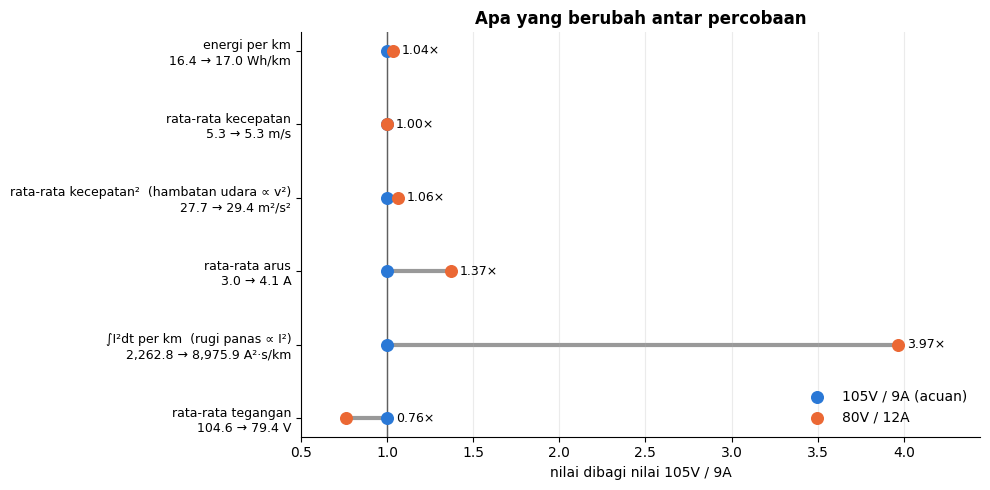

In [20]:
dist_km = lambda df: df["distance_m"].iloc[-1] / 1000
FACTORS = [  # (nama, fungsi, satuan)
    ("energi per km", lambda df: df["energy_Wh"].iloc[-1] / dist_km(df), "Wh/km"),
    ("rata-rata kecepatan", lambda df: df["speed_ms"].mean(), "m/s"),
    ("rata-rata kecepatan²  (hambatan udara ∝ v²)", lambda df: (df["speed_ms"] ** 2).mean(), "m²/s²"),
    ("rata-rata arus", lambda df: df["current_A"].mean(), "A"),
    ("∫I²dt per km  (rugi panas ∝ I²)", lambda df: (df["current_A"] ** 2 * df["dt_s"]).sum() / dist_km(df), "A²·s/km"),
    ("rata-rata tegangan", lambda df: df["voltage_V"].mean(), "V"),
]
factors = pd.DataFrame([
    {"faktor": name, "satuan": unit, BASE: f(data[BASE]), OTHER: f(data[OTHER])}
    for name, f, unit in FACTORS
]).iloc[::-1].reset_index(drop=True)
factors["rasio"] = factors[OTHER] / factors[BASE]

fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(factors))
ax.hlines(y, 1, factors["rasio"], color="#999", linewidth=3, zorder=1)
ax.scatter(np.ones(len(factors)), y, s=70, color=COLORS[BASE], zorder=2, label=f"{BASE} (acuan)")
ax.scatter(factors["rasio"], y, s=70, color=COLORS[OTHER], zorder=2, label=OTHER)
ax.axvline(1, color="#444", linewidth=1, zorder=0)
for yi, r in zip(y, factors["rasio"]):
    ax.text(max(r, 1) + 0.05, yi, f"{r:.2f}×", va="center", fontsize=9)
ax.set_yticks(y)
ax.set_yticklabels([
    f"{row.faktor}\n{row[BASE]:,.1f} → {row[OTHER]:,.1f} {row.satuan}" for _, row in factors.iterrows()
], fontsize=9)
ax.set_xlim(0.5, factors["rasio"].max() * 1.12)
ax.grid(axis="y", visible=False)
ax.set_xlabel(f"nilai dibagi nilai {BASE}")
ax.set_title("Apa yang berubah antar percobaan")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

**Cerita lengkapnya:**

1. Kedua percobaan finis dalam **waktu yang sama** (~35 menit) dengan **rata-rata kecepatan yang sama** (rasio 1,00). Jadi perbedaan efisiensi tidak datang dari seberapa cepat mobil melaju.
2. Mobil 80V memakai strategi **gas-glide**: gas penuh 12 A, lalu gliding, lalu gas lagi. Rata-rata arusnya hanya ~1,4 kali lebih besar, tetapi **∫I²dt per km ~4 kali lebih besar**, karena kuadrat arus puncak sangat besar. Tegangan ~24% lebih rendah membuat arus untuk daya yang sama semakin besar.
3. Kecepatan yang naik-turun juga menaikkan rata-rata v² ~6%, sehingga hambatan udara sedikit bertambah.
4. Tanjakan membebani kedua percobaan sama besar dan menyumbang porsi besar dari total energi. Karena itu pengali-pengali tadi menyusut menjadi **~4% lebih banyak energi per km** secara keseluruhan.

**Pelajaran untuk lomba hemat energi:** untuk waktu tempuh yang sama, **melaju stabil** lebih hemat daripada gas-glide. Gliding-lah di turunan (gratis), bukan di jalan datar. Gunakan tegangan setinggi mungkin agar daya yang sama mengalir dengan arus yang lebih kecil.

## Langkah 7 — Tambahan: bagaimana jika batas arus diperkecil?

Dari Langkah 5 dan 6 kita tahu: arus kecil = rugi panas kecil. Jadi apakah cukup menurunkan **batas arus kontroler** serendah mungkin?

Dua percobaan tambahan memakai tegangan yang sama (105V) dan gaya mengemudi yang sama (stabil, target finis ~35 menit), dengan batas arus **5 A** dan **2 A**, dalam kondisi normal (tanpa angin). Aturan lomba: **3 lap (~11,03 km) dalam 36 menit**. Mobil yang belum menyelesaikan 3 lap saat waktu habis dinyatakan **DNF** (*did not finish*), dan hasil efisiensinya tidak dihitung.

In [21]:
BATAS_WAKTU_MENIT = 36
JARAK_LOMBA_KM = 3 * 3.675

EXTRA = [("data/DataASC_105V_5A.csv", "105V / 5A"), ("data/DataASC_105V_2A.csv", "105V / 2A")]
data_arus = {BASE: data[BASE]}               # 105V / 9A sebagai pembanding
for (path, label), color in zip(EXTRA, ["#1baf7a", "#eda100"]):
    COLORS[label] = color
    data_arus[label] = load_attempt(path, label)

hasil = pd.DataFrame({
    label: {
        "waktu (menit)": df["time_s"].iloc[-1] / 60,
        "jarak (km)": df["distance_m"].iloc[-1] / 1000,
        "energi (Wh)": df["energy_Wh"].iloc[-1],
        "efisiensi (km/kWh)": df["efficiency_km_per_kWh"].iloc[-1],
        "status": "FINIS" if df["distance_m"].iloc[-1] / 1000 >= JARAK_LOMBA_KM - 0.01 else "DNF",
    }
    for label, df in data_arus.items()
})
hasil.round(2)

,105V / 9A,105V / 5A,105V / 2A
waktu (menit),34.9968,34.9968,35.9968
jarak (km),11.024093,11.024524,7.724394
energi (Wh),180.876589,178.06538,116.096206
efisiensi (km/kWh),60.948147,61.912787,66.534422
status,FINIS,FINIS,DNF


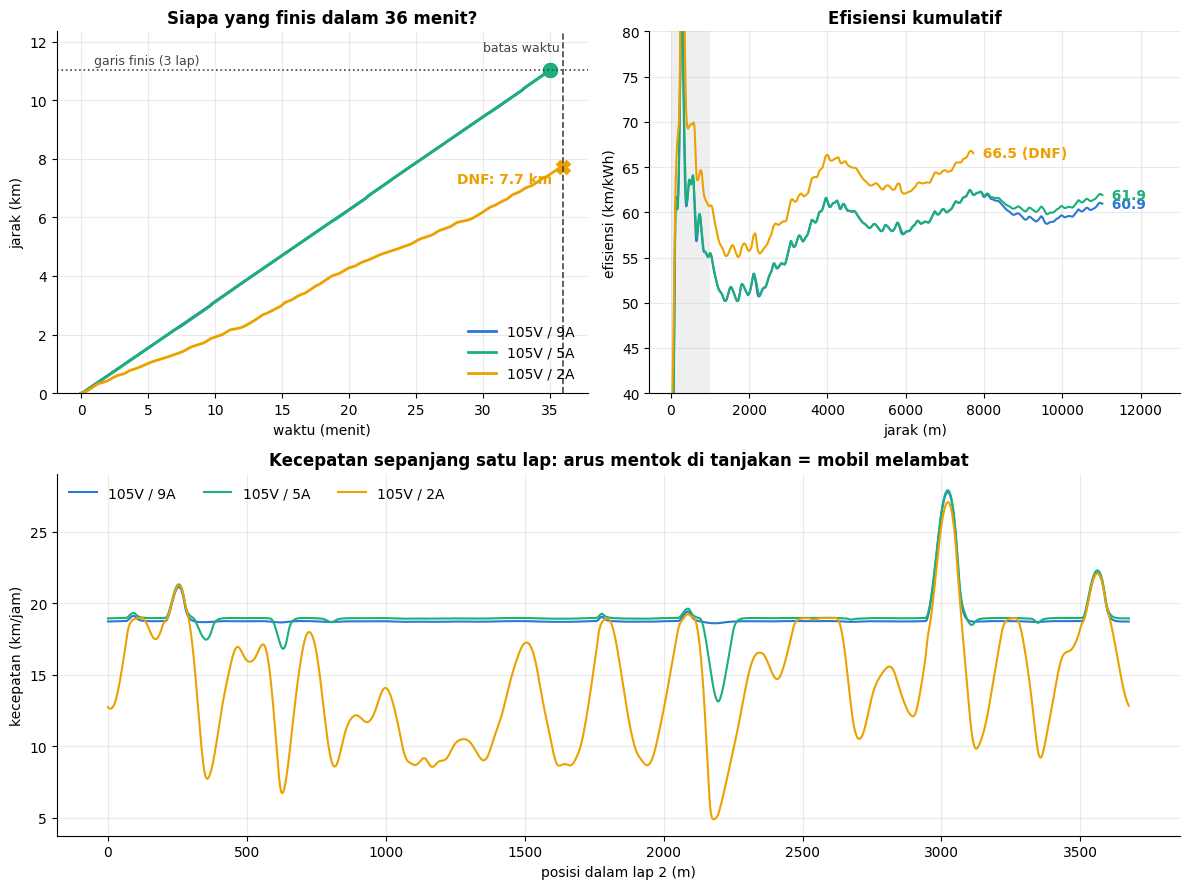

In [22]:
fig = plt.figure(figsize=(12, 9))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 1, 2)

for label, df in data_arus.items():
    dnf = hasil.loc["status", label] == "DNF"
    menit, km = df["time_s"] / 60, df["distance_m"] / 1000

    # (kiri atas) jarak terhadap waktu: siapa yang finis sebelum waktu habis?
    ax1.plot(menit, km, color=COLORS[label], linewidth=2, label=label)
    ax1.plot(menit.iloc[-1], km.iloc[-1], "X" if dnf else "o", color=COLORS[label], markersize=10)
    if dnf:
        ax1.annotate(f"DNF: {km.iloc[-1]:.1f} km", (menit.iloc[-1], km.iloc[-1]), xytext=(-8, -4),
                     textcoords="offset points", ha="right", va="top", color=COLORS[label], fontweight="bold")

    # (kanan atas) efisiensi kumulatif: arus kecil memang lebih efisien
    eff = df["efficiency_km_per_kWh"].iloc[-1]
    ax2.plot(df["distance_m"], df["efficiency_km_per_kWh"], color=COLORS[label], linewidth=1.5, label=label)
    ax2.text(df["distance_m"].iloc[-1], eff, f"  {eff:.1f}" + (" (DNF)" if dnf else ""),
             color=COLORS[label], va="center", fontweight="bold")

    # (bawah) kecepatan sepanjang lap 2: di mana mobil tertahan batas arus?
    one = df[df["lap"] == 2]
    ax3.plot(one["distance_m"] - one["distance_m"].iloc[0], one["speed_ms"] * 3.6, color=COLORS[label],
             linewidth=1.5, label=label)

ax1.axvline(BATAS_WAKTU_MENIT, color="#444", linestyle="--", linewidth=1.2)
ax1.axhline(JARAK_LOMBA_KM, color="#444", linestyle=":", linewidth=1.2)
ax1.text(BATAS_WAKTU_MENIT, JARAK_LOMBA_KM * 1.06, "batas waktu ", ha="right", color="#444", fontsize=9)
ax1.text(1, JARAK_LOMBA_KM + 0.2, "garis finis (3 lap)", color="#444", fontsize=9)
ax1.set_ylim(0, JARAK_LOMBA_KM * 1.12)
ax1.set_xlabel("waktu (menit)")
ax1.set_ylabel("jarak (km)")
ax1.set_title(f"Siapa yang finis dalam {BATAS_WAKTU_MENIT} menit?")
ax1.legend(frameon=False, loc="lower right")

ax2.axvspan(0, 1000, color="#999", alpha=0.15, linewidth=0)
ax2.set_ylim(40, 80)
ax2.set_xlim(right=11025 * 1.18)
ax2.set_xlabel("jarak (m)")
ax2.set_ylabel("efisiensi (km/kWh)")
ax2.set_title("Efisiensi kumulatif")

ax3.set_xlabel("posisi dalam lap 2 (m)")
ax3.set_ylabel("kecepatan (km/jam)")
ax3.set_title("Kecepatan sepanjang satu lap: arus mentok di tanjakan = mobil melambat")
ax3.legend(frameon=False, ncol=3, loc="upper left")
fig.tight_layout()
plt.show()

**Cara membacanya:**

- **Kecepatan (bawah):** dengan batas 9 A mobil menjaga ~19 km/jam di seluruh lap. Dengan **5 A**, arus mentok hanya di tanjakan paling curam (~600 m dan ~2.150 m), jadi mobil sedikit melambat di sana lalu kembali ke kecepatan jelajah. Dengan **2 A**, arus mentok di hampir setiap tanjakan: daya maksimal hanya ~210 W (105 V × 2 A), sehingga di tanjakan mobil merayap hingga ~5–7 km/jam.
- **Efisiensi (kanan atas):** semakin kecil batas arus, semakin tinggi efisiensinya (2 A ≈ 66,5 km/kWh, sekitar 9% lebih tinggi dari 9 A). Alasannya sama dengan Langkah 5–6: arus kecil berarti rugi panas I²R kecil, dan mobil yang merayap membayar hambatan udara lebih kecil.
- **Jarak vs waktu (kiri atas):** harga yang dibayar adalah waktu. Percobaan 5 A masih finis dalam ~35 menit, sama dengan 9 A. Percobaan 2 A tidak mampu menjaga kecepatan di tanjakan, sehingga baru menempuh **~7,7 km dari 11,03 km** saat 36 menit habis. Hasilnya **DNF**, dan efisiensinya yang tinggi tidak dihitung sama sekali.

Efisiensi 5 A (61,9) sedikit lebih tinggi dari 9 A (61,0). Sebagian karena lap 3 percobaan 9 A melawan angin depan, sedangkan percobaan 5 A tanpa angin, dan sebagian karena arus puncak di tanjakan lebih kecil.

**Pelajaran:** efisiensi hanya berarti jika mobil **finis**. Strategi terbaik adalah melaju **stabil, selambat mungkin tetapi masih di atas kecepatan rata-rata minimum** (di sini 11,03 km / 36 menit ≈ 5,1 m/s ≈ 18,4 km/jam). Batas arus harus cukup besar agar mobil tidak merayap di tanjakan dan kehilangan terlalu banyak waktu.